# Model Comparison for DFU Classification — Best Model Selection

## Objective
Systematically compare all 6 trained architectures and pick the **best model for final training**.

## Why Macro F1 Is The Primary Metric
The dataset is **imbalanced** (Ischaemia: 152, Both: 416 vs Infection: 1,708, None: 1,725).
- **Accuracy** is misleading — a model predicting only the majority class gets ~43%.
- **Macro F1** treats every class equally regardless of size, penalising models that ignore minority classes.
- We also report **MCC** (Matthew's Correlation Coefficient) as a secondary metric — the most informative single score for imbalanced multiclass problems.

## Models Evaluated
| # | Architecture | Key Property |
|---|---|---|
| 1 | MobileNetV2 | Lightweight / mobile-ready |
| 2 | ResNet50 | Baseline deep residual |
| 3 | ResNet101 | Deeper residual |
| 4 | EfficientNetV2-S | Compound-scaled efficiency |
| 5 | GoogLeNet | Inception multi-scale |
| 6 | DenseNet121 | Dense feature reuse |

## Evaluation Protocol
- **5-fold stratified cross-validation** → `CV Accuracy (mean ± std)`
- **Best-fold validation set** → full metrics (Macro F1, per-class F1, AUC, MCC, etc.)
- All metrics loaded from `results/<model>_comprehensive_metrics.json`

---

## 1. Setup & Configuration

In [36]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display

# ── Plotting defaults (publication quality) ─────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

# Project colour palette
PALETTE = ['#0f457e', '#3d6a99', '#619ac5', '#64adb3', '#a2d5c6', '#d4e8c2']
sns.set_palette(PALETTE)

# ── Paths ────────────────────────────────────────────────────────────────
RESULTS_DIR = Path('results')
OUTPUT_DIR  = RESULTS_DIR / 'comparison'
TABLES_DIR  = OUTPUT_DIR / 'tables'
FIGURES_DIR = OUTPUT_DIR / 'figures'

for d in [TABLES_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['Both', 'Infection', 'Ischaemia', 'None']

print('Setup complete.')
print(f'Output tables  → {TABLES_DIR}')
print(f'Output figures → {FIGURES_DIR}')

Setup complete.
Output tables  → results\comparison\tables
Output figures → results\comparison\figures


## 2. Load All Model Results

In [19]:
# ── Load every *_comprehensive_metrics.json in results/ ──────────────
json_files = sorted(RESULTS_DIR.glob('*_comprehensive_metrics.json'))

models = {}  # key: display name, value: full JSON dict
for jf in json_files:
    with open(jf) as f:
        data = json.load(f)
    key = data['model_info']['model_name']  # e.g. "DenseNet121"
    models[key] = data
    print(f'  [OK] {key:20s} ← {jf.name}')

print(f'\nLoaded {len(models)} / 6 models.')
assert len(models) == 6, 'Expected 6 models — check results/ folder.'

# ── Show dataset imbalance ────────────────────────────────────────────
dist = list(models.values())[0]['dataset_info']['class_distribution']
total = sum(dist.values())
print(f'\nDataset: {total} samples')
for cls, n in dist.items():
    print(f'  {cls:12s}: {n:5d}  ({n/total*100:5.1f}%)')
print(f'\nImbalance ratio (max/min): {max(dist.values())/min(dist.values()):.1f}x')

  [OK] DenseNet121          ← densenet121_comprehensive_metrics.json
  [OK] EfficientNetV2S      ← efficientnetv2s_comprehensive_metrics.json
  [OK] GoogLeNet            ← googlenet_comprehensive_metrics.json
  [OK] MobileNetV2          ← mobilenetv2_comprehensive_metrics.json
  [OK] ResNet101            ← resnet101_comprehensive_metrics.json
  [OK] ResNet50             ← resnet50_comprehensive_metrics.json

Loaded 6 / 6 models.

Dataset: 4001 samples
  Both        :   416  ( 10.4%)
  Infection   :  1708  ( 42.7%)
  Ischaemia   :   152  (  3.8%)
  None        :  1725  ( 43.1%)

Imbalance ratio (max/min): 11.3x


## 3. Master Metrics Table
Build a single DataFrame with **every metric that matters** for model selection.
Sorted by **Macro F1** (the primary metric for imbalanced data).

In [20]:
rows = []
for name, r in models.items():
    cv  = r['cross_validation']
    val = r['validation_results']
    pc  = val['per_class_metrics']

    rows.append({
        'Model':            name,
        # ── Cross-validation ──────────────────────────────────────────
        'CV_Acc_Mean':      cv['mean_accuracy'],
        'CV_Acc_Std':       cv['std_accuracy'],
        'CV_Acc_Min':       cv['min_accuracy'],
        'CV_Acc_Max':       cv['max_accuracy'],
        'Avg_Epochs':       cv['average_epochs'],
        # ── Best-fold validation (full eval) ──────────────────────────
        'Val_Accuracy':     val['accuracy'],
        'Macro_F1':         val['macro_f1'],
        'Macro_Precision':  val['macro_precision'],
        'Macro_Recall':     val['macro_recall'],
        'Macro_Specificity':val['macro_specificity'],
        'Macro_AUC':        val['macro_auc'],
        'Weighted_AUC':     val['weighted_auc'],
        'MCC':              val['matthews_corrcoef'],
        'Cohen_Kappa':      val['cohen_kappa'],
        'Log_Loss':         val['log_loss'],
        # ── Per-class F1 ──────────────────────────────────────────────
        **{f'F1_{cls}': pc[cls]['f1_score'] for cls in CLASS_NAMES},
        # ── Per-class AUC ─────────────────────────────────────────────
        **{f'AUC_{cls}': pc[cls]['auc'] for cls in CLASS_NAMES},
        # ── Per-class Recall (sensitivity) ────────────────────────────
        **{f'Recall_{cls}': pc[cls]['recall'] for cls in CLASS_NAMES},
        # ── Per-class Precision ───────────────────────────────────────
        **{f'Precision_{cls}': pc[cls]['precision'] for cls in CLASS_NAMES},
    })

df = pd.DataFrame(rows)

# Primary sort by Macro F1 (our main metric)
df = df.sort_values('Macro_F1', ascending=False).reset_index(drop=True)
df.insert(0, 'Rank', range(1, len(df) + 1))

print('Master table built — sorted by Macro F1 (descending)')
df[['Rank','Model','CV_Acc_Mean','CV_Acc_Std','Val_Accuracy',
    'Macro_F1','Macro_Precision','Macro_Recall','MCC','Macro_AUC']].round(4)

Master table built — sorted by Macro F1 (descending)


,Rank,Model,CV_Acc_Mean,CV_Acc_Std,Val_Accuracy,Macro_F1,Macro_Precision,Macro_Recall,MCC,Macro_AUC
0,1,EfficientNetV2S,0.8081,0.0172,0.9012,0.9100,0.8906,0.9326,0.8424,0.9848
1,2,MobileNetV2,0.7538,0.0214,0.8527,0.8687,0.8451,0.9007,0.7653,0.9669
2,3,DenseNet121,0.7416,0.0190,0.8102,0.8478,0.8237,0.8779,0.6983,0.9532
3,4,ResNet50,0.7071,0.0133,0.7725,0.7842,0.7503,0.8363,0.6394,0.9309
4,5,ResNet101,0.7563,0.0232,0.7603,0.7834,0.7400,0.8535,0.6270,0.9375
5,6,GoogLeNet,0.7896,0.0098,0.5412,0.4085,0.5735,0.4048,0.2726,0.7613


## 4. Multi-Metric Ranking
Rank every model on the **metrics that matter for imbalanced classification**.
Each model gets a rank (1=best) per metric, then we average ranks.

In [21]:
# Metrics where higher is better
rank_cols = ['Macro_F1', 'MCC', 'Cohen_Kappa', 'Macro_AUC',
             'Macro_Recall', 'Macro_Precision', 'CV_Acc_Mean', 'Val_Accuracy']

rank_df = df[['Model'] + rank_cols].copy()

# Build per-metric rank (1 = best); method='min' ensures ties get the same rank
for col in rank_cols:
    rank_df[f'{col}_rank'] = rank_df[col].rank(ascending=False, method='min').astype(int)

# Average rank across all metrics
rank_only_cols = [c for c in rank_df.columns if c.endswith('_rank')]
rank_df['Avg_Rank'] = rank_df[rank_only_cols].mean(axis=1)
rank_df = rank_df.sort_values('Avg_Rank').reset_index(drop=True)

print('='*100)
print('MODEL RANKING — Sorted by Average Rank across imbalance-aware metrics')
print('='*100)
print(f'{"PRIMARY metric":>20s}: Macro F1  (treats all classes equally)')
print(f'{"SECONDARY metric":>20s}: MCC       (best single metric for imbalanced data)')
print('='*100)

display_rank = rank_df[['Model'] + rank_cols + ['Avg_Rank']].copy()
for c in rank_cols:
    display_rank[c] = display_rank[c].apply(lambda x: f'{x:.4f}')
display_rank['Avg_Rank'] = display_rank['Avg_Rank'].round(2)
display(display_rank)

# Save
rank_df.to_csv(TABLES_DIR / '01_model_ranking.csv', index=False)
print(f'Saved → {TABLES_DIR / "01_model_ranking.csv"}')

MODEL RANKING — Sorted by Average Rank across imbalance-aware metrics
      PRIMARY metric: Macro F1  (treats all classes equally)
    SECONDARY metric: MCC       (best single metric for imbalanced data)


,Model,Macro_F1,MCC,Cohen_Kappa,Macro_AUC,Macro_Recall,Macro_Precision,CV_Acc_Mean,Val_Accuracy,Avg_Rank
0,EfficientNetV2S,0.9100,0.8424,0.8418,0.9848,0.9326,0.8906,0.8081,0.9012,1.00
1,MobileNetV2,0.8687,0.7653,0.7643,0.9669,0.9007,0.8451,0.7538,0.8527,2.25
2,DenseNet121,0.8478,0.6983,0.6971,0.9532,0.8779,0.8237,0.7416,0.8102,3.25
3,ResNet50,0.7842,0.6394,0.6387,0.9309,0.8363,0.7503,0.7071,0.7725,4.50
4,ResNet101,0.7834,0.6270,0.6238,0.9375,0.8535,0.7400,0.7563,0.7603,4.50
5,GoogLeNet,0.4085,0.2726,0.2185,0.7613,0.4048,0.5735,0.7896,0.5413,5.50


Saved → results\comparison\tables\01_model_ranking.csv


## 5. Per-Class F1 Analysis
Critical to verify that the top model doesn't sacrifice minority classes (Ischaemia, Both).

In [22]:
# Build per-class table
pc_rows = []
for _, row in df.iterrows():
    for cls in CLASS_NAMES:
        pc_rows.append({
            'Model': row['Model'],
            'Class': cls,
            'F1': row[f'F1_{cls}'],
            'Precision': row[f'Precision_{cls}'],
            'Recall': row[f'Recall_{cls}'],
            'AUC': row[f'AUC_{cls}'],
        })
pc_df = pd.DataFrame(pc_rows)

# Pivot: F1 per model×class
f1_pivot = pc_df.pivot(index='Model', columns='Class', values='F1')[CLASS_NAMES]
# Reorder by overall Macro F1
order = df.sort_values('Macro_F1', ascending=False)['Model'].tolist()
f1_pivot = f1_pivot.loc[order]

print('Per-class F1 Scores (rows sorted by Macro F1):')
display(f1_pivot.round(4))

# Show validation support from the best model's fold
# (±1 sample across models due to different best folds in stratified CV)
best_model_name = df.iloc[0]['Model']
sample = models[best_model_name]['validation_results']['per_class_metrics']
print(f'\nValidation support per class (from {best_model_name} best fold; ±1 across folds):')
for cls in CLASS_NAMES:
    print(f'  {cls:12s}: {sample[cls]["support"]} samples')

# Save
pc_df.round(4).to_csv(TABLES_DIR / '02_per_class_metrics.csv', index=False)
print(f'\nSaved → {TABLES_DIR / "02_per_class_metrics.csv"}')

Per-class F1 Scores (rows sorted by Macro F1):


Class,Both,Infection,Ischaemia,None
Model,,,,
EfficientNetV2S,0.9425,0.8886,0.9062,0.9026
MobileNetV2,0.9176,0.8441,0.8696,0.8434
DenseNet121,0.8914,0.7761,0.9118,0.8119
ResNet50,0.8786,0.7489,0.7368,0.7726
ResNet101,0.8466,0.7468,0.7949,0.7453
GoogLeNet,0.1800,0.6432,0.3830,0.4280



Validation support per class (from EfficientNetV2S best fold; ±1 across folds):
  Both        : 83 samples
  Infection   : 342 samples
  Ischaemia   : 30 samples
  None        : 345 samples

Saved → results\comparison\tables\02_per_class_metrics.csv


## 6. Cross-Validation Stability
A model that scores high on one fold but drops on another is unreliable.

Cross-validation accuracy per model (5-fold stratified):


,Model,Mean,Std,Min,Max,Range,CI95_Low,CI95_High,Avg_Epochs
0,EfficientNetV2S,0.8081,0.0172,0.7862,0.8338,0.0475,0.7743,0.8418,29.2
1,GoogLeNet,0.7896,0.0098,0.7715,0.7988,0.0272,0.7704,0.8087,30.0
2,ResNet101,0.7563,0.0232,0.7138,0.7815,0.0678,0.7109,0.8017,29.4
3,MobileNetV2,0.7538,0.0214,0.7212,0.7865,0.0653,0.7118,0.7958,24.4
4,DenseNet121,0.7416,0.0190,0.7150,0.7703,0.0553,0.7043,0.7789,28.4
5,ResNet50,0.7071,0.0133,0.6900,0.7238,0.0338,0.6810,0.7332,28.6


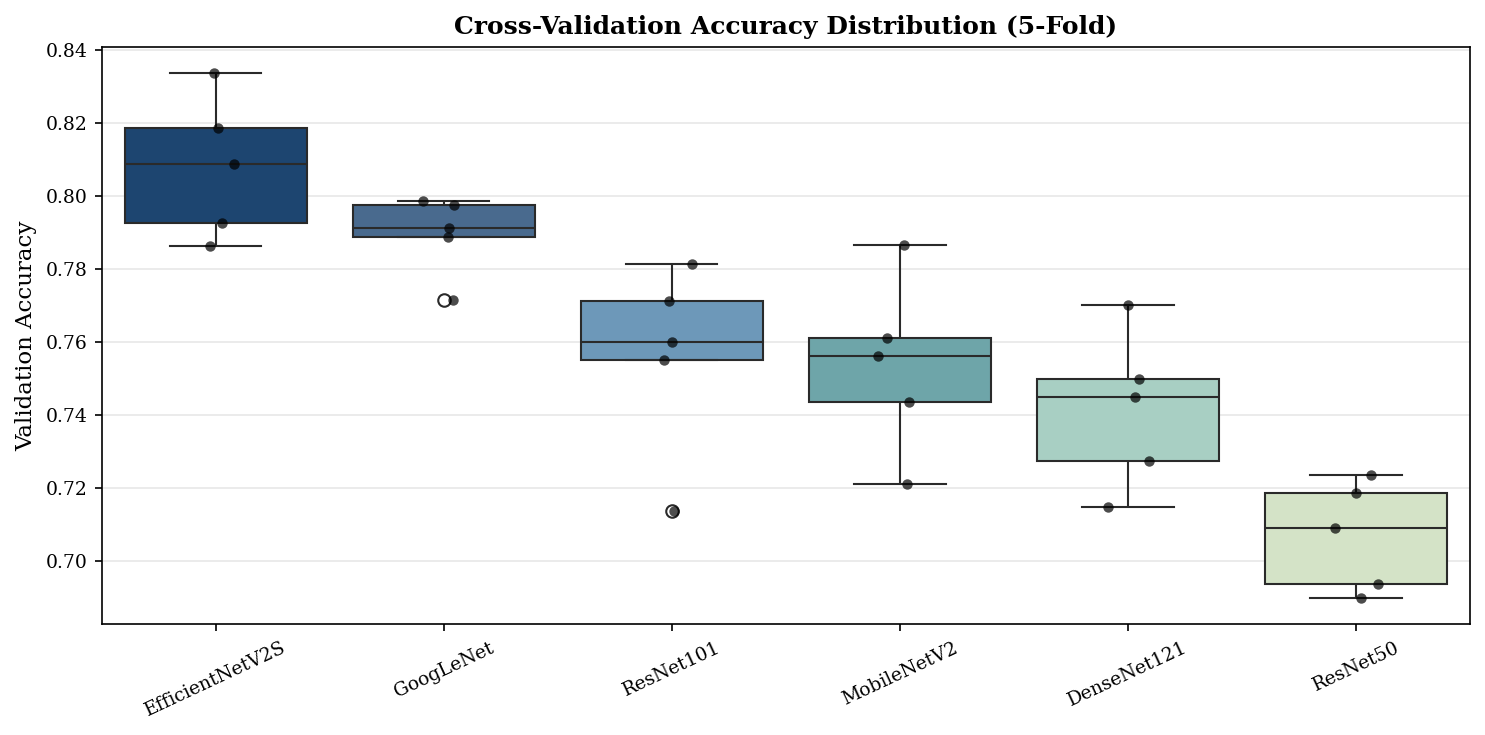

Saved → results\comparison\figures\fig1_cv_boxplot.png


In [35]:
cv_rows = []
for name, r in models.items():
    cv = r['cross_validation']
    folds = cv['individual_folds']
    accs  = [f['best_val_accuracy'] for f in folds]
    cv_rows.append({
        'Model': name,
        'Mean': np.mean(accs),
        'Std':  np.std(accs),
        'Min':  np.min(accs),
        'Max':  np.max(accs),
        'Range': np.max(accs) - np.min(accs),
        'CI95_Low':  np.mean(accs) - 1.96 * np.std(accs),
        'CI95_High': np.mean(accs) + 1.96 * np.std(accs),
        'Avg_Epochs': cv['average_epochs'],
    })

cv_df = pd.DataFrame(cv_rows).sort_values('Mean', ascending=False).reset_index(drop=True)

print('Cross-validation accuracy per model (5-fold stratified):')
display(cv_df.round(4))

# Box-plot data
fold_data = []
for name, r in models.items():
    for f in r['cross_validation']['individual_folds']:
        fold_data.append({'Model': name, 'Fold': f['fold'], 'Accuracy': f['best_val_accuracy']})
fold_df = pd.DataFrame(fold_data)

fig, ax = plt.subplots(figsize=(10, 5))
order_cv = cv_df['Model'].tolist()
sns.boxplot(data=fold_df, x='Model', y='Accuracy', hue='Model',
            order=order_cv, hue_order=order_cv, palette=PALETTE, legend=False, ax=ax)
sns.stripplot(data=fold_df, x='Model', y='Accuracy', order=order_cv,
              color='black', size=5, alpha=0.7, ax=ax)
ax.set_title('Cross-Validation Accuracy Distribution (5-Fold)', fontweight='bold')
ax.set_ylabel('Validation Accuracy')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_cv_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR / "fig1_cv_boxplot.png"}')

## 7. Visualisations
### 7.1 Macro F1 Comparison (Primary Metric)

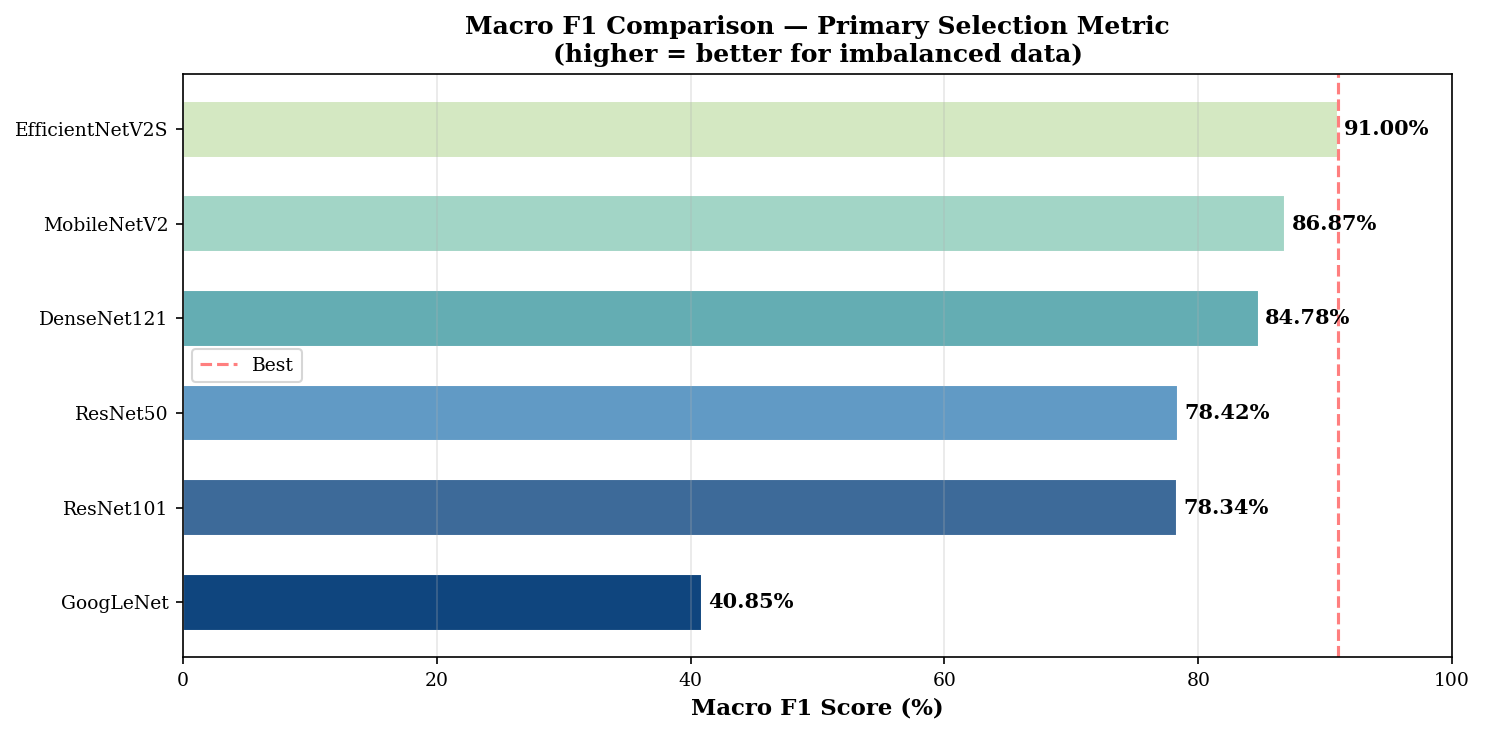

Saved → results\comparison\figures\fig2_macro_f1_comparison.png


In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

ordered = df.sort_values('Macro_F1', ascending=True)
y = range(len(ordered))
bars = ax.barh(y, ordered['Macro_F1'] * 100, color=PALETTE[:len(ordered)], edgecolor='white', height=0.6)

# Annotate values
for i, (_, row) in enumerate(ordered.iterrows()):
    ax.text(row['Macro_F1']*100 + 0.5, i, f"{row['Macro_F1']*100:.2f}%",
            va='center', fontweight='bold', fontsize=10)

ax.set_yticks(y)
ax.set_yticklabels(ordered['Model'])
ax.set_xlabel('Macro F1 Score (%)', fontweight='bold')
ax.set_title('Macro F1 Comparison — Primary Selection Metric\n(higher = better for imbalanced data)',
             fontweight='bold')
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.3)
ax.axvline(x=ordered['Macro_F1'].max()*100, color='red', linestyle='--', alpha=0.5, label='Best')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_macro_f1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR / "fig2_macro_f1_comparison.png"}')

### 7.2 Multi-Metric Radar Chart

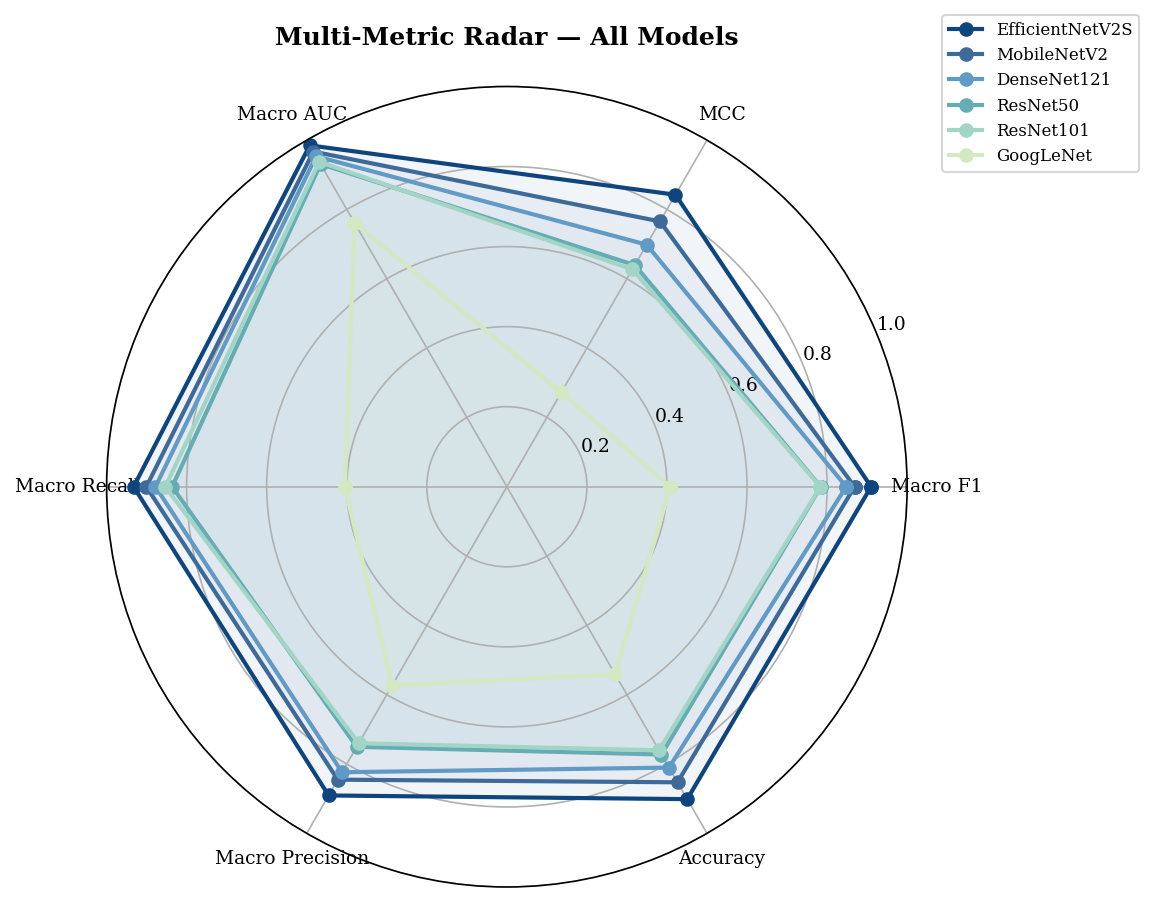

Saved → results\comparison\figures\fig3_radar_chart.png


In [25]:
# Radar chart comparing top metrics across all models
radar_metrics = ['Macro_F1', 'MCC', 'Macro_AUC', 'Macro_Recall', 'Macro_Precision', 'Val_Accuracy']
radar_labels  = ['Macro F1', 'MCC', 'Macro AUC', 'Macro Recall', 'Macro Precision', 'Accuracy']

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (_, row) in enumerate(df.iterrows()):
    values = [row[m] for m in radar_metrics]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=PALETTE[i % len(PALETTE)])
    ax.fill(angles, values, alpha=0.05, color=PALETTE[i % len(PALETTE)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('Multi-Metric Radar — All Models', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR / "fig3_radar_chart.png"}')

### 7.3 Per-Class F1 Heatmap

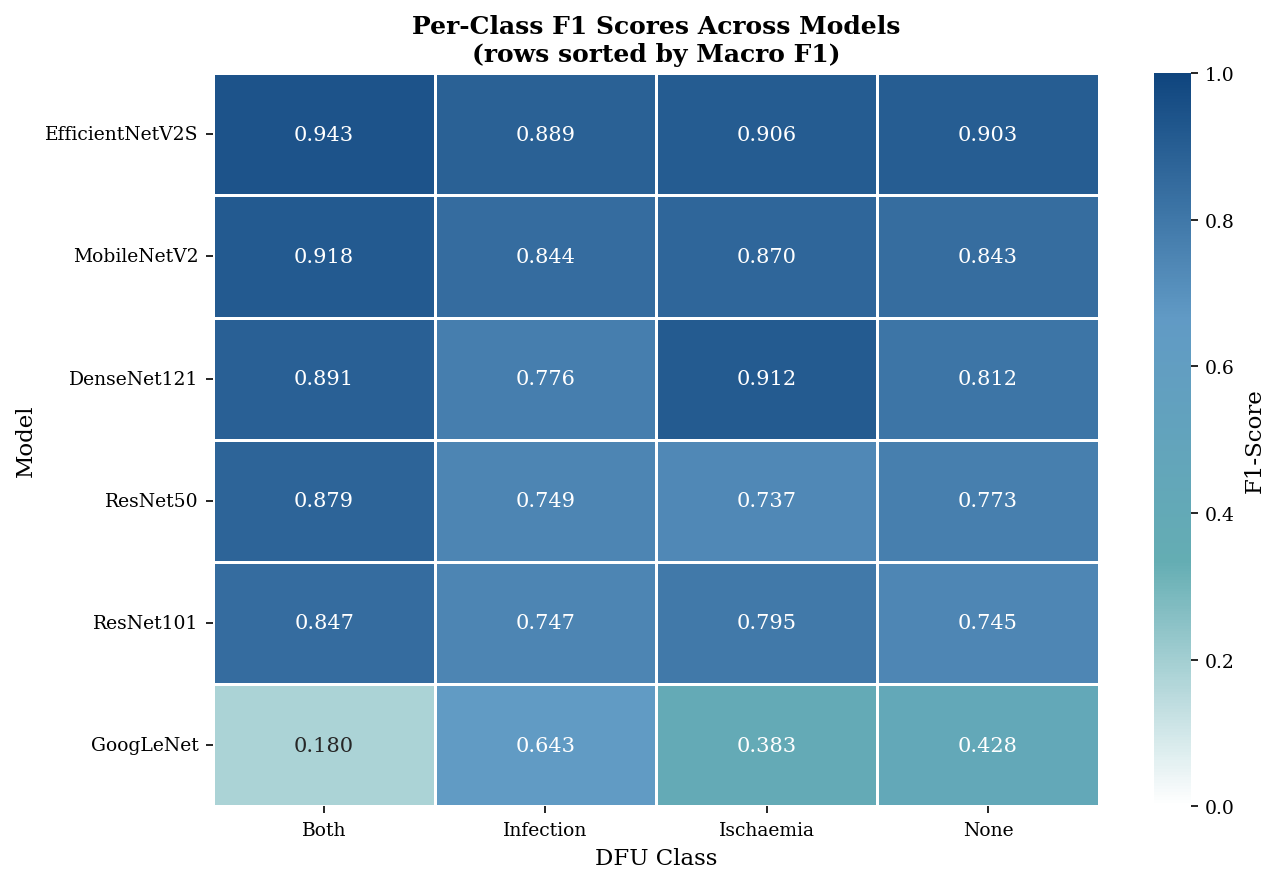

Saved → results\comparison\figures\fig4_f1_heatmap.png


In [26]:
fig, ax = plt.subplots(figsize=(9, 6))

cmap = LinearSegmentedColormap.from_list('custom', ['#ffffff', '#64adb3', '#619ac5', '#0f457e'])

sns.heatmap(f1_pivot, annot=True, fmt='.3f', cmap=cmap,
            linewidths=0.5, vmin=0, vmax=1, ax=ax,
            cbar_kws={'label': 'F1-Score'})

ax.set_title('Per-Class F1 Scores Across Models\n(rows sorted by Macro F1)', fontweight='bold')
ax.set_xlabel('DFU Class')
ax.set_ylabel('Model')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4_f1_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR / "fig4_f1_heatmap.png"}')

### 7.4 Confusion Matrices — All Models

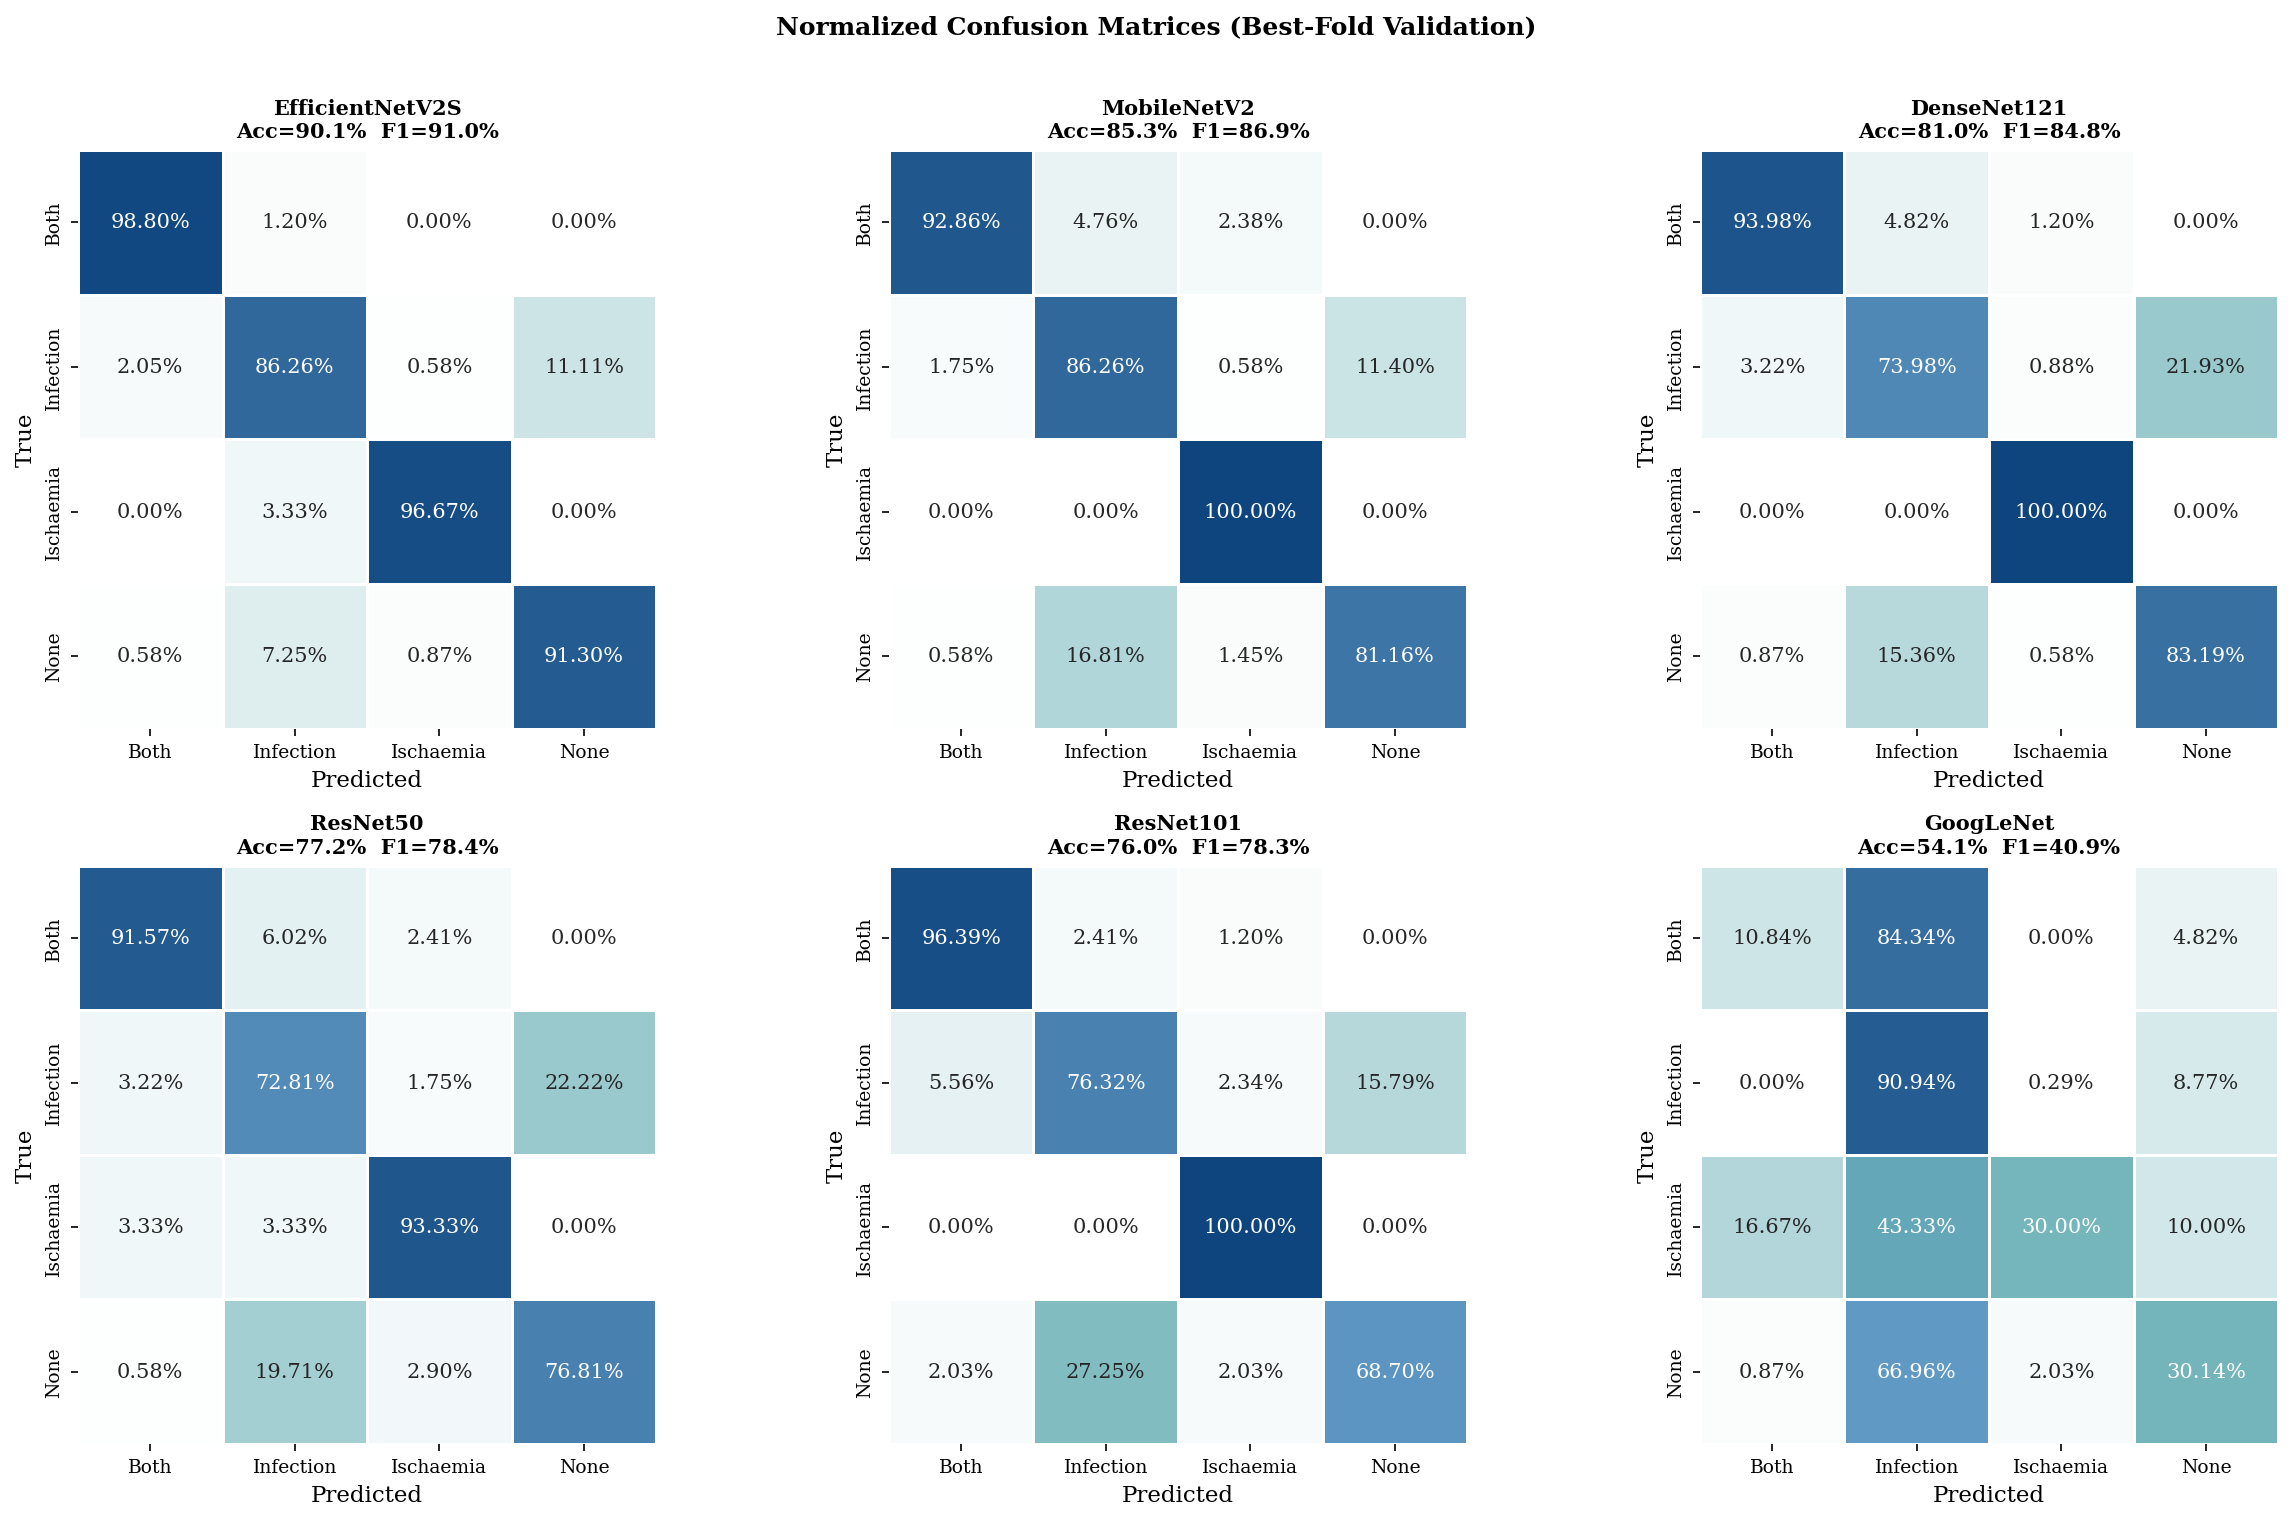

Saved → results\comparison\figures\fig5_confusion_matrices.png


In [27]:
n = len(models)
cols = 3
rows_n = (n + cols - 1) // cols

fig, axes = plt.subplots(rows_n, cols, figsize=(5.5*cols, 5*rows_n))
axes = axes.flatten()

cmap = LinearSegmentedColormap.from_list('custom', ['#ffffff', '#64adb3', '#619ac5', '#0f457e'])

# Plot in Macro F1 order
ordered_names = df.sort_values('Macro_F1', ascending=False)['Model'].tolist()

for idx, name in enumerate(ordered_names):
    r = models[name]
    cm = np.array(r['validation_results']['confusion_matrix']['normalized'])
    labels = r['validation_results']['confusion_matrix']['labels']
    acc = r['validation_results']['accuracy']
    mf1 = r['validation_results']['macro_f1']

    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='.2%', cmap=cmap,
                xticklabels=labels, yticklabels=labels, ax=ax,
                vmin=0, vmax=1, square=True, linewidths=0.5,
                cbar=False)
    ax.set_title(f'{name}\nAcc={acc*100:.1f}%  F1={mf1*100:.1f}%', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

for idx in range(n, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Normalized Confusion Matrices (Best-Fold Validation)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR / "fig5_confusion_matrices.png"}')

### 7.5 ROC Curves — All Models (Macro-Average)

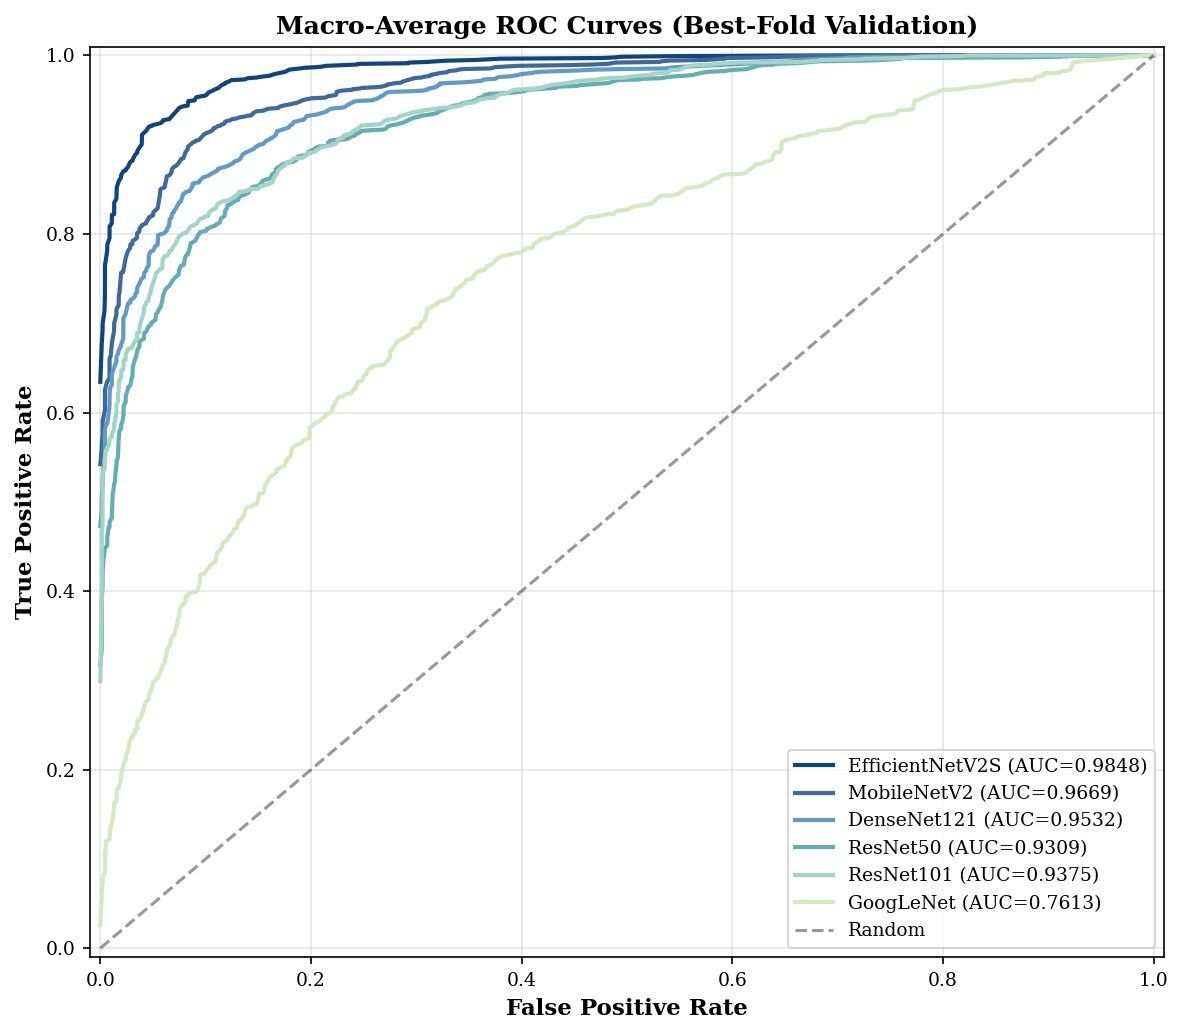

Saved → results\comparison\figures\fig6_roc_macro.png


In [28]:
fig, ax = plt.subplots(figsize=(8, 7))

for i, name in enumerate(ordered_names):
    roc = models[name]['validation_results']['roc_curves']['macro_average']
    ax.plot(roc['fpr'], roc['tpr'],
            label=f"{name} (AUC={roc['auc']:.4f})",
            linewidth=2, color=PALETTE[i % len(PALETTE)])

ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('Macro-Average ROC Curves (Best-Fold Validation)', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig6_roc_macro.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR / "fig6_roc_macro.png"}')

### 7.6 Per-Class ROC — Best Model

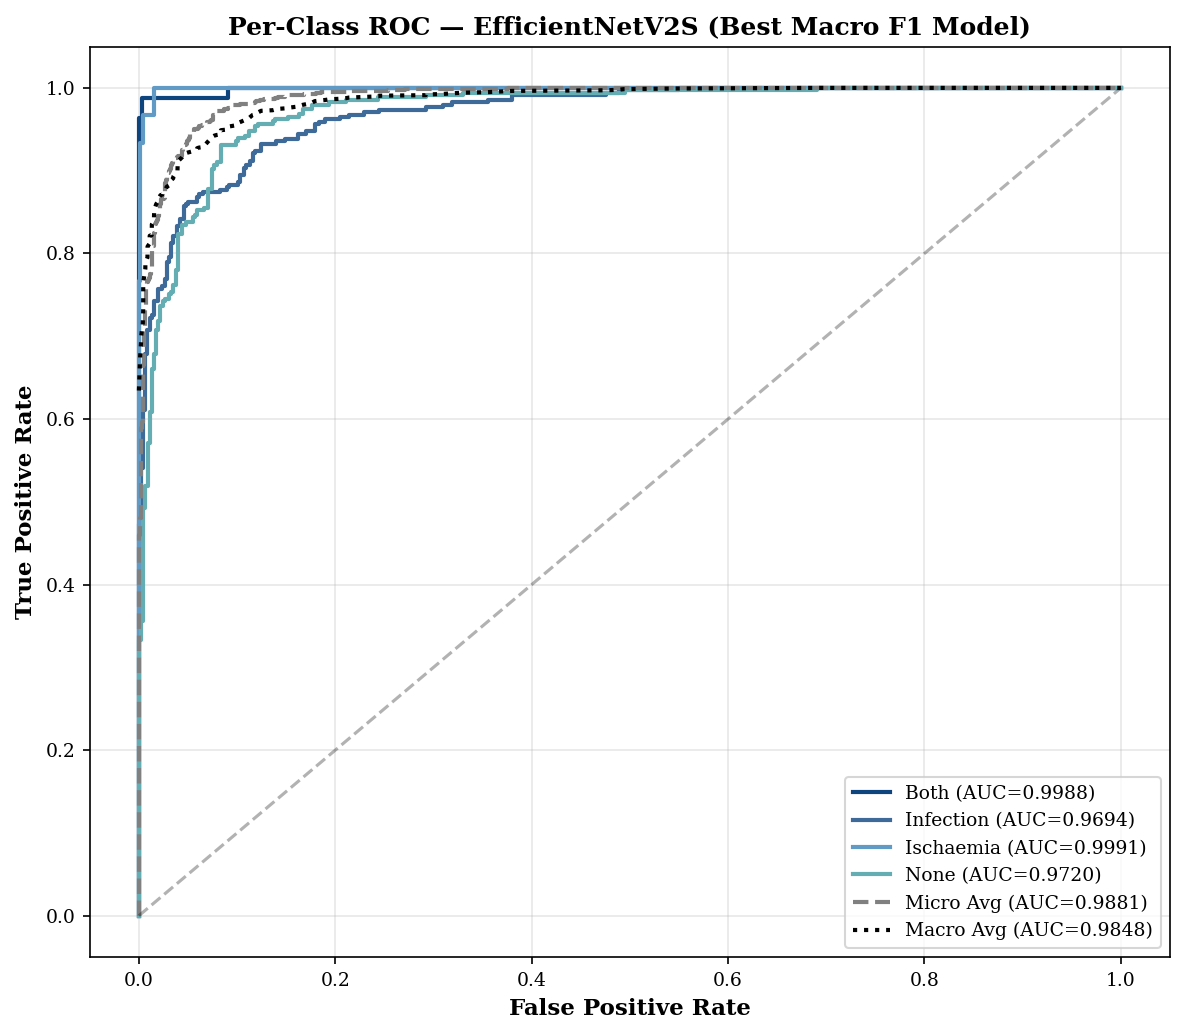

Saved → results\comparison\figures\fig7_roc_best_model.png


In [29]:
best_name = df.iloc[0]['Model']  # already sorted by Macro F1
best_roc  = models[best_name]['validation_results']['roc_curves']

fig, ax = plt.subplots(figsize=(8, 7))
for i, cls in enumerate(CLASS_NAMES):
    ax.plot(best_roc[cls]['fpr'], best_roc[cls]['tpr'],
            label=f"{cls} (AUC={best_roc[cls]['auc']:.4f})",
            linewidth=2, color=PALETTE[i % len(PALETTE)])

# Add micro & macro
ax.plot(best_roc['micro_average']['fpr'], best_roc['micro_average']['tpr'],
        label=f"Micro Avg (AUC={best_roc['micro_average']['auc']:.4f})",
        linewidth=2, linestyle='--', color='gray')
ax.plot(best_roc['macro_average']['fpr'], best_roc['macro_average']['tpr'],
        label=f"Macro Avg (AUC={best_roc['macro_average']['auc']:.4f})",
        linewidth=2, linestyle=':', color='black')

ax.plot([0,1], [0,1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title(f'Per-Class ROC — {best_name} (Best Macro F1 Model)', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig7_roc_best_model.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR / "fig7_roc_best_model.png"}')

## 8. Statistical Significance — Is the Best Model Really Better?
Compare the top-2 models fold-by-fold to check if the difference is significant.

> **Note:** Per-fold Macro F1 is **not** stored in the JSON results, so we use **fold-level accuracy** for this paired t-test. With only 5 folds the statistical power is limited (df = 4) — treat the p-value as indicative, not definitive.

In [30]:
# Get fold accuracies for the top-2 models (by Macro F1)
# NOTE: Only fold-level accuracy is available; per-fold Macro F1 is not in the JSON.
top2 = df.head(2)['Model'].tolist()

fold_accs = {}
for name in top2:
    folds = models[name]['cross_validation']['individual_folds']
    fold_accs[name] = [f['best_val_accuracy'] for f in folds]

a, b = top2
t_stat, p_val = stats.ttest_rel(fold_accs[a], fold_accs[b])  # paired t-test (df=4)

print('='*80)
print('STATISTICAL COMPARISON — Paired t-test on 5-fold CV accuracies')
print('  (per-fold Macro F1 not available; using accuracy as proxy)')
print('='*80)
print(f'  Model A: {a}')
print(f'    Fold accuracies: {[round(x,4) for x in fold_accs[a]]}')
print(f'    Mean: {np.mean(fold_accs[a]):.4f} ± {np.std(fold_accs[a]):.4f}')
print(f'  Model B: {b}')
print(f'    Fold accuracies: {[round(x,4) for x in fold_accs[b]]}')
print(f'    Mean: {np.mean(fold_accs[b]):.4f} ± {np.std(fold_accs[b]):.4f}')
print(f'\n  t-statistic: {t_stat:.4f}')
print(f'  p-value:     {p_val:.4f}')
print(f'  degrees of freedom: {len(fold_accs[a]) - 1}')

if p_val < 0.05:
    print(f'\n  >>> The difference IS statistically significant (p < 0.05).')
    print(f'    -> {a} is significantly better than {b}.')
else:
    print(f'\n  >>> The difference is NOT statistically significant (p = {p_val:.3f} >= 0.05).')
    print(f'    -> Both models perform comparably; choose based on other criteria')
    print(f'      (Macro F1, per-class performance, model size, inference speed).')

print(f'\n  ⚠ Caveat: With only 5 folds, this test has limited statistical power.')
print(f'    The best-fold Macro F1 gap remains the stronger evidence.')
print('='*80)

STATISTICAL COMPARISON — Paired t-test on 5-fold CV accuracies
  (per-fold Macro F1 not available; using accuracy as proxy)
  Model A: EfficientNetV2S
    Fold accuracies: [0.7928, 0.8337, 0.8087, 0.8187, 0.7863]
    Mean: 0.8081 ± 0.0172
  Model B: MobileNetV2
    Fold accuracies: [0.7865, 0.7562, 0.7612, 0.7438, 0.7212]
    Mean: 0.7538 ± 0.0214

  t-statistic: 4.1382
  p-value:     0.0144
  degrees of freedom: 4

  >>> The difference IS statistically significant (p < 0.05).
    -> EfficientNetV2S is significantly better than MobileNetV2.

  ⚠ Caveat: With only 5 folds, this test has limited statistical power.
    The best-fold Macro F1 gap remains the stronger evidence.


## 9. Publication-Ready Summary Table

In [31]:
# Publication table: CV Acc (mean +/- std) | Val Acc | Macro F1 | Macro P | Macro R | MCC | Macro AUC
pub = df[['Rank','Model','CV_Acc_Mean','CV_Acc_Std','Val_Accuracy',
          'Macro_F1','Macro_Precision','Macro_Recall','MCC','Macro_AUC','Cohen_Kappa','Log_Loss']].copy()

# Format CV Accuracy as "mean +/- std"
pub['CV_Accuracy'] = pub.apply(
    lambda r: f"{r['CV_Acc_Mean']*100:.2f} +/- {r['CV_Acc_Std']*100:.2f}", axis=1)

# Convert to percentage strings
for col in ['Val_Accuracy','Macro_F1','Macro_Precision','Macro_Recall']:
    pub[col] = pub[col].apply(lambda x: f'{x*100:.2f}')
for col in ['MCC','Macro_AUC','Cohen_Kappa','Log_Loss']:
    pub[col] = pub[col].apply(lambda x: f'{x:.4f}')

pub_final = pub[['Rank','Model','CV_Accuracy','Val_Accuracy',
                  'Macro_F1','Macro_Precision','Macro_Recall',
                  'MCC','Macro_AUC','Cohen_Kappa','Log_Loss']]

print('='*130)
print('PUBLICATION-READY COMPARISON TABLE (sorted by Macro F1)')
print('='*130)
display(pub_final)
print('='*130)

# Save
pub_final.to_csv(TABLES_DIR / '03_publication_table.csv', index=False)
print(f'Saved -> {TABLES_DIR / "03_publication_table.csv"}')

PUBLICATION-READY COMPARISON TABLE (sorted by Macro F1)


,Rank,Model,CV_Accuracy,Val_Accuracy,Macro_F1,Macro_Precision,Macro_Recall,MCC,Macro_AUC,Cohen_Kappa,Log_Loss
0,1,EfficientNetV2S,80.81 +/- 1.72,90.12,91.00,89.06,93.26,0.8424,0.9848,0.8418,0.2490
1,2,MobileNetV2,75.38 +/- 2.14,85.27,86.87,84.51,90.07,0.7653,0.9669,0.7643,0.3572
2,3,DenseNet121,74.16 +/- 1.90,81.02,84.78,82.37,87.79,0.6983,0.9532,0.6971,0.4411
3,4,ResNet50,70.71 +/- 1.33,77.25,78.42,75.03,83.63,0.6394,0.9309,0.6387,0.5508
4,5,ResNet101,75.63 +/- 2.32,76.03,78.34,74.00,85.35,0.6270,0.9375,0.6238,0.5223
5,6,GoogLeNet,78.96 +/- 0.98,54.12,40.85,57.35,40.48,0.2726,0.7613,0.2185,1.6362


Saved -> results\comparison\tables\03_publication_table.csv


## 10. Minority Class Deep Dive
Focus on **Ischaemia** (152 samples) and **Both** (416 samples) — the minority classes that matter most clinically.

In [32]:
# Focus on minority classes: Ischaemia (152) and Both (416)
minority_classes = ['Ischaemia', 'Both']
majority_classes = ['Infection', 'None']

print('='*90)
print('MINORITY CLASS PERFORMANCE (Critical for clinical usefulness)')
print('='*90)

for cls in minority_classes:
    print(f'\n  Class: {cls} (support in val set: {sample[cls]["support"]})')
    print(f'  {"Model":20s}  {"F1":>8s}  {"Precision":>10s}  {"Recall":>8s}  {"AUC":>8s}')
    print('  ' + '-'*60)
    for _, row in df.iterrows():
        print(f'  {row["Model"]:20s}  {row[f"F1_{cls}"]:8.4f}  {row[f"Precision_{cls}"]:10.4f}  '
              f'{row[f"Recall_{cls}"]:8.4f}  {row[f"AUC_{cls}"]:8.4f}')

print('\n' + '='*90)
print('MAJORITY CLASS PERFORMANCE')
print('='*90)

for cls in majority_classes:
    print(f'\n  Class: {cls} (support in val set: {sample[cls]["support"]})')
    print(f'  {"Model":20s}  {"F1":>8s}  {"Precision":>10s}  {"Recall":>8s}  {"AUC":>8s}')
    print('  ' + '-'*60)
    for _, row in df.iterrows():
        print(f'  {row["Model"]:20s}  {row[f"F1_{cls}"]:8.4f}  {row[f"Precision_{cls}"]:10.4f}  '
              f'{row[f"Recall_{cls}"]:8.4f}  {row[f"AUC_{cls}"]:8.4f}')

print('\n' + '='*90)

MINORITY CLASS PERFORMANCE (Critical for clinical usefulness)

  Class: Ischaemia (support in val set: 30)
  Model                       F1   Precision    Recall       AUC
  ------------------------------------------------------------
  EfficientNetV2S         0.9062      0.8529    0.9667    0.9991
  MobileNetV2             0.8696      0.7692    1.0000    0.9999
  DenseNet121             0.9118      0.8378    1.0000    0.9995
  ResNet50                0.7368      0.6087    0.9333    0.9933
  ResNet101               0.7949      0.6596    1.0000    0.9981
  GoogLeNet               0.3830      0.5294    0.3000    0.8440

  Class: Both (support in val set: 83)
  Model                       F1   Precision    Recall       AUC
  ------------------------------------------------------------
  EfficientNetV2S         0.9425      0.9011    0.9880    0.9988
  MobileNetV2             0.9176      0.9070    0.9286    0.9986
  DenseNet121             0.8914      0.8478    0.9398    0.9922
  ResNet50  

### 10.1 Grouped Bar — F1 per Class per Model

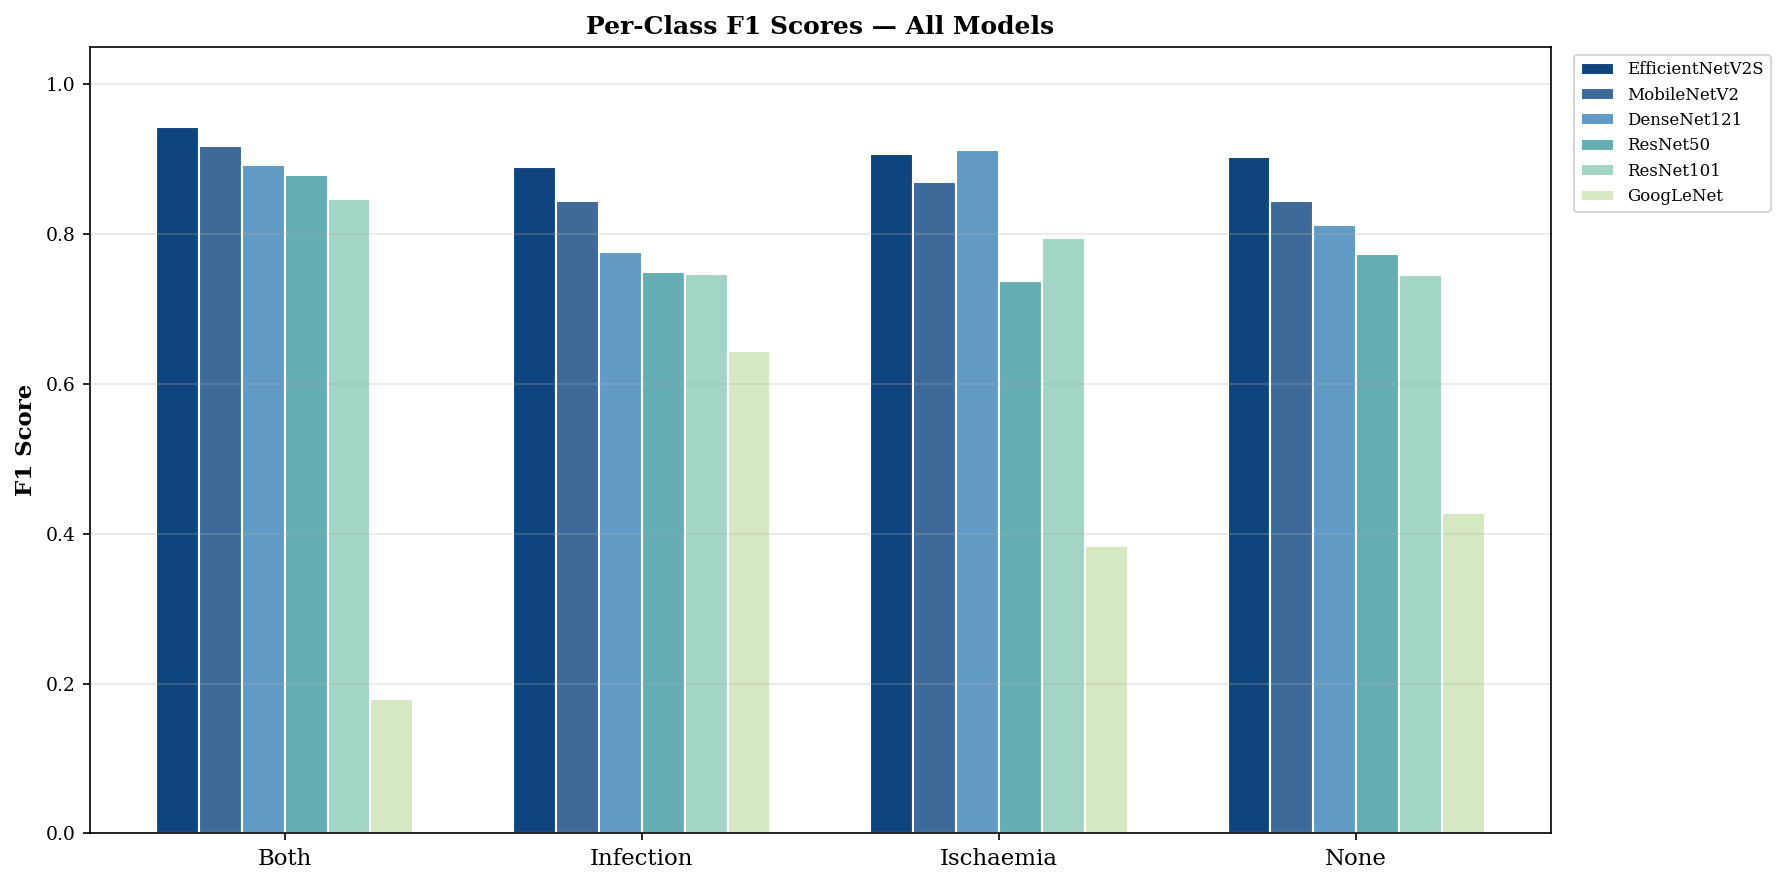

Saved -> results\comparison\figures\fig8_per_class_f1_bars.png


In [33]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(CLASS_NAMES))
width = 0.12
n_models = len(ordered_names)

for i, name in enumerate(ordered_names):
    vals = [df.loc[df['Model']==name, f'F1_{cls}'].values[0] for cls in CLASS_NAMES]
    offset = (i - n_models/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=name, color=PALETTE[i % len(PALETTE)], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylabel('F1 Score', fontweight='bold')
ax.set_title('Per-Class F1 Scores — All Models', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig8_per_class_f1_bars.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved -> {FIGURES_DIR / "fig8_per_class_f1_bars.png"}')

## 11. Final Recommendation

In [34]:
best = df.iloc[0]
runner_up = df.iloc[1]

print('\n' + '#'*80)
print('  FINAL MODEL SELECTION RECOMMENDATION')
print('#'*80)

print(f'\n  >>> BEST MODEL: {best["Model"]}')
print(f'  ----------------------------------------------------------')
print(f'  Macro F1 (PRIMARY):  {best["Macro_F1"]*100:.2f}%')
print(f'  MCC (SECONDARY):     {best["MCC"]:.4f}')
print(f'  CV Accuracy:         {best["CV_Acc_Mean"]*100:.2f}% +/- {best["CV_Acc_Std"]*100:.2f}%')
print(f'  Validation Accuracy: {best["Val_Accuracy"]*100:.2f}%')
print(f'  Macro AUC:           {best["Macro_AUC"]:.4f}')
print(f'  Cohen Kappa:         {best["Cohen_Kappa"]:.4f}')
print(f'  Log Loss:            {best["Log_Loss"]:.4f}')

print(f'\n  Per-class F1:')
for cls in CLASS_NAMES:
    print(f'    {cls:12s}: {best[f"F1_{cls}"]*100:.2f}%')

print(f'\n  ----------------------------------------------------------')
print(f'  Runner-up: {runner_up["Model"]}')
print(f'    Macro F1: {runner_up["Macro_F1"]*100:.2f}%   MCC: {runner_up["MCC"]:.4f}')

gap = (best['Macro_F1'] - runner_up['Macro_F1']) * 100
print(f'\n  Gap (Macro F1): +{gap:.2f} percentage points')

print(f'\n  RECOMMENDATION:')
print(f'  -> Use {best["Model"]} for final training on the full training set.')
print(f'  -> Then evaluate on the held-out TEST set for final reporting.')
print('\n' + '#'*80)

# Save full comparison to JSON
summary = {
    'best_model': best['Model'],
    'primary_metric': 'Macro_F1',
    'best_macro_f1': round(float(best['Macro_F1']), 4),
    'best_mcc': round(float(best['MCC']), 4),
    'best_cv_acc': f"{best['CV_Acc_Mean']*100:.2f} +/- {best['CV_Acc_Std']*100:.2f}",
    'ranking': [{
        'Rank': int(row['Rank']),
        'Model': row['Model'],
        'Macro_F1': round(float(row['Macro_F1']), 4),
        'MCC': round(float(row['MCC']), 4),
        'Val_Accuracy': round(float(row['Val_Accuracy']), 4),
        'Macro_AUC': round(float(row['Macro_AUC']), 4),
    } for _, row in df.iterrows()],
}
with open(TABLES_DIR / 'best_model_selection.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f'\nSaved -> {TABLES_DIR / "best_model_selection.json"}')


################################################################################
  FINAL MODEL SELECTION RECOMMENDATION
################################################################################

  >>> BEST MODEL: EfficientNetV2S
  ----------------------------------------------------------
  Macro F1 (PRIMARY):  91.00%
  MCC (SECONDARY):     0.8424
  CV Accuracy:         80.81% +/- 1.72%
  Validation Accuracy: 90.12%
  Macro AUC:           0.9848
  Cohen Kappa:         0.8418
  Log Loss:            0.2490

  Per-class F1:
    Both        : 94.25%
    Infection   : 88.86%
    Ischaemia   : 90.62%
    None        : 90.26%

  ----------------------------------------------------------
  Runner-up: MobileNetV2
    Macro F1: 86.87%   MCC: 0.7653

  Gap (Macro F1): +4.13 percentage points

  RECOMMENDATION:
  -> Use EfficientNetV2S for final training on the full training set.
  -> Then evaluate on the held-out TEST set for final reporting.

#############################################